# Sampling v2 — Video-level stratified sampling with balanced code coverage

**Sampling logic:**
1. **20 % of videos** sampled, stratified by conference
2. **Greedy chunk selection per video** — picks chunks whose codes are most under-represented in the running global count (Evey's approach: skip chunks that only add already-common codes)
3. **2 utterances per chunk** — utterances that carry actual annotations
4. **`ai_annotations` column** — Gemini's full justification per code: `[{code_name: explanation}]`

**Output** matches `ev-verification.csv` format:
locators → `ai_annotations` → blank human slots (`c1/c1-vf/c1-ep` × 3) → behavioural features

**Configurable:** `TARGET_VIDEO_FRACTION`, `MAX_CHUNKS_PER_VIDEO`, `UTTERANCES_PER_CHUNK`

In [ ]:
# --- Standardized output management (figures + tables) ---
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

CANDIDATE_ROOTS = [Path.cwd(), Path.cwd().parent, Path.cwd() / 'analysis_v2']
ANALYSIS_V2 = next((p for p in CANDIDATE_ROOTS if (p / 'data').exists() and (p / 'notebooks').exists()), None)
if ANALYSIS_V2 is None:
    raise RuntimeError('Could not resolve analysis_v2 root. Run from repo root or analysis_v2/notebooks.')

# Set this per run/notebook (examples: 'baseline', 'quality/minimal', 'quality/rephrased')
CONDITION = 'baseline'
RESULTS_DIR = ANALYSIS_V2 / 'results'
FIGURES_DIR = RESULTS_DIR / 'figures' / CONDITION
TABLES_DIR = RESULTS_DIR / 'tables' / CONDITION
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print('CONDITION  :', CONDITION)
print('FIGURES_DIR:', FIGURES_DIR)
print('TABLES_DIR :', TABLES_DIR)

_ORIG_PLT_SHOW = plt.show
_AUTO_FIG_COUNTER = {'n': 0}

def save_current_figure(name: str | None = None, dpi: int = 200):
    fig = plt.gcf()
    if name is None:
        _AUTO_FIG_COUNTER['n'] += 1
        name = f"figure_{_AUTO_FIG_COUNTER['n']:03d}.png"
    out_path = FIGURES_DIR / name
    fig.savefig(out_path, dpi=dpi, bbox_inches='tight')
    return out_path

def show_and_save(name: str | None = None, dpi: int = 200):
    out_path = save_current_figure(name=name, dpi=dpi)
    _ORIG_PLT_SHOW()
    print(f'Saved figure: {out_path}')

plt.show = show_and_save

def save_results_bundle(bundle: dict, stem: str = 'analysis_results'):
    rows = []
    json_payload = {}
    for key, value in bundle.items():
        if isinstance(value, pd.DataFrame):
            out_csv = TABLES_DIR / f'{stem}__{key}.csv'
            value.to_csv(out_csv, index=False)
            rows.append({'name': key, 'type': 'dataframe', 'path': str(out_csv), 'rows': int(len(value))})
        else:
            json_payload[key] = value

    if json_payload:
        json_path = TABLES_DIR / f'{stem}__extras.json'
        with open(json_path, 'w', encoding='utf-8') as f:
            json.dump(json_payload, f, indent=2, ensure_ascii=False, default=str)
        rows.append({'name': 'extras', 'type': 'json', 'path': str(json_path), 'rows': None})

    manifest = pd.DataFrame(rows)
    manifest_path = TABLES_DIR / f'{stem}__manifest.csv'
    manifest.to_csv(manifest_path, index=False)
    print(f'Saved results manifest: {manifest_path}')
    return manifest



In [1]:
import os, json, glob, re, math, random
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

# ── repo root ────────────────────────────────────────────────────────────────
_HERE = os.path.abspath('')
if os.path.basename(_HERE) == 'notebooks':
    os.chdir(os.path.join(_HERE, '..', '..'))
elif os.path.basename(_HERE) == 'analysis_v2':
    os.chdir(os.path.join(_HERE, '..'))
print('Working directory:', os.getcwd())

# ── config ───────────────────────────────────────────────────────────────────
RANDOM_SEED            = 42
BASE_DIR               = 'outputs'
TARGET_VIDEO_FRACTION  = 0.20   # 20 % of unique videos
MAX_CHUNKS_PER_VIDEO   = 3      # max chunks selected per video
UTTERANCES_PER_CHUNK   = 2      # utterances picked per chunk (max 2 per Evey)
OUTPUT_EXCEL           = 'analysis_v2/notebooks/sampled_v2.xlsx'
DIST_PNG               = 'analysis_v2/notebooks/sampled_v2_distribution.png'

# Codes excluded from balance scoring — annotated on every utterance anyway;
# humans will catch ~30 incidentally while watching for other codes (Evey, 2024)
BALANCE_EXCLUDE = {'Pronoun Framing'}

# Video filename patterns that indicate bad/glitchy recordings — exclude entirely
# Covers: maybe_wrong, glitch, trim_end, trimend, problem, time_off,
#         time_wrong, controls_issue, missed (per Evey)
BAD_VIDEO_PATTERNS = [
    'maybe_wrong', 'glitch', 'trim_end', 'trimend',
    'problem', 'time_off', 'time_wrong', 'controls_issue', 'missed',
]

random.seed(RANDOM_SEED)

def is_bad_video(fname: str) -> bool:
    """Return True if the filename matches a known bad-recording pattern."""
    fname_lower = fname.lower()
    return any(p in fname_lower for p in BAD_VIDEO_PATTERNS)

def is_high_level_code(name: str) -> bool:
    """Keep Title-Case names; drop snake_case subcodes that leak in."""
    name = name.strip()
    return bool(name) and name.lower() != 'none' and '_' not in name

def format_ai_annotations(codes: list) -> str:
    """
    Format Gemini codes as a list-of-dicts string matching ev-verification.csv:
      [{'Code Name': 'evidence — explanation'}, ...]
    """
    items = []
    for c in codes:
        cn   = c.get('code_name', '').strip()
        ev   = c.get('evidence', '').strip()
        expl = c.get('explanation', '').strip()
        if not is_high_level_code(cn):
            continue
        body = ' — '.join(filter(None, [ev, expl]))
        items.append({cn: body})
    return str(items) if items else ''


Working directory: /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis


## 1 · Build video registry

Group every chunk file under its parent video (strip `_chunk\d+` suffix).
Each entry stores the conf/session/file_path and all utterances with their codes.

In [2]:
all_json_files = sorted(glob.glob(os.path.join(BASE_DIR, '**', '*.json'), recursive=True))
print(f'Total JSON files: {len(all_json_files)}')
print(f'Reading from   : {os.path.abspath(BASE_DIR)}')

# video_registry[video_base] = {
#   'conf': ..., 'session': ...,
#   'chunks': [ {'chunk_file': fname, 'file_path': ..., 'utterances': [...]} ]
# }
video_registry = defaultdict(lambda: {'conf': '', 'session': '', 'chunks': []})

skipped = 0
excluded_bad = 0
global_code_freq = Counter()   # total occurrences across whole dataset

for fp in all_json_files:
    rel   = os.path.relpath(fp, BASE_DIR)
    parts = rel.split(os.sep)
    conf    = parts[0] if len(parts) > 0 else ''
    session = parts[1] if len(parts) > 1 else ''
    fname   = parts[2] if len(parts) > 2 else os.path.basename(fp)

    # skip bad/glitchy recordings
    if is_bad_video(fname):
        excluded_bad += 1
        continue

    # derive the parent video base name (strip _chunkN)
    video_base = re.sub(r'_chunk\d+$', '', fname.replace('.json', ''))

    try:
        with open(fp) as f:
            data = json.load(f)
    except Exception:
        skipped += 1
        continue

    utterances_raw = data.get('utterance_annotations', [])
    chunk_utts = []

    for utt in utterances_raw:
        codes_raw  = utt.get('codes', [])
        code_names = [c.get('code_name','').strip()
                      for c in codes_raw if is_high_level_code(c.get('code_name',''))]
        global_code_freq.update(code_names)

        chunk_utts.append({
            'timestamp'       : utt.get('timestamp', ''),
            'speaker'         : utt.get('speaker', ''),
            'transcript'      : utt.get('transcript', ''),
            'ai_annotations'  : format_ai_annotations(codes_raw),
            'code_names'      : code_names,
            'n_codes'         : len(code_names),
            'speaking_duration': utt.get('speaking_duration_seconds', ''),
            'nod_count'       : utt.get('nod_count', ''),
            'shared_affect'   : utt.get('shared_affect', ''),
            'any_smile_other' : utt.get('any_smile_other', ''),
            'distracted_count': utt.get('distracted_participant_count', ''),
            'interruption_type': utt.get('interruption_type', ''),
            'overlap'         : utt.get('audible_backchannel', ''),
            'vocal_enthusiasm': utt.get('vocal_enthusiasm', ''),
        })

    video_registry[video_base]['conf']    = conf
    video_registry[video_base]['session'] = session
    video_registry[video_base]['chunks'].append({
        'chunk_file': fname,
        'file_path' : os.path.abspath(fp),   # full absolute path
        'utterances': chunk_utts,
    })

print(f'Excluded (bad recording name): {excluded_bad}')
print(f'Skipped (empty/invalid JSON) : {skipped}')
print(f'Unique videos                : {len(video_registry)}')
print(f'20 % of videos               : {math.ceil(len(video_registry) * TARGET_VIDEO_FRACTION)}')
print()
print('Global code frequencies (top 15):')
for code, cnt in global_code_freq.most_common(15):
    print(f'  {cnt:6d}  {code}')


Total JSON files: 1325
Reading from   : /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/outputs


Excluded (bad recording name): 149
Skipped (empty/invalid JSON) : 35
Unique videos                : 228
20 % of videos               : 46

Global code frequencies (top 15):
   12692  Pronoun Framing
    6061  Knowledge Sharing
    3927  Idea Management
    3524  Evaluation Practices
    3070  Coordination and Decision Practices
    2864  Information Seeking
    2048  Participation Dynamics
    1753  Integration Practices
    1751  Relational Climate
     356  Epistemic Bridging
     173  Broader Significance
     159  Complementarity Articulation
     117  Idea Ownership and Attribution
     100  Role Anticipation
      87  Future-Oriented Language


## 2 · Sample 20 % of videos (stratified by conference)

In [3]:
# Group videos by conference
conf_videos = defaultdict(list)
for vbase, vdata in video_registry.items():
    conf_videos[vdata['conf']].append(vbase)

total_videos  = len(video_registry)
target_videos = math.ceil(total_videos * TARGET_VIDEO_FRACTION)

print(f'Total unique videos : {total_videos}')
print(f'Target sample (20%) : {target_videos}')
print()

# Proportional allocation per conference — sort by size ascending so
# small conferences don't get over-allocated
sampled_videos = []
confs_sorted   = sorted(conf_videos.keys(), key=lambda c: len(conf_videos[c]))

remaining = target_videos
for i, conf in enumerate(confs_sorted):
    remaining_confs = len(confs_sorted) - i
    videos = conf_videos[conf]
    take   = min(len(videos), math.ceil(remaining / remaining_confs))
    chosen = random.sample(videos, take)
    sampled_videos.extend([(v, conf) for v in chosen])
    remaining -= take
    print(f'  {conf}: sampled {take} / {len(videos)} videos')

print(f'\nTotal videos sampled: {len(sampled_videos)}')

Total unique videos : 228
Target sample (20%) : 46

  2022MND: sampled 6 / 9 videos
  2021NES: sampled 6 / 11 videos
  2021CMC: sampled 6 / 22 videos
  2021MZT: sampled 6 / 25 videos
  2021SLU: sampled 6 / 27 videos
  2021MND: sampled 6 / 38 videos
  2021ABI: sampled 5 / 46 videos
  2020NES: sampled 5 / 50 videos

Total videos sampled: 46


## 3 · Greedy chunk selection per video

For each sampled video, score every chunk by the sum of **inverse global frequencies** of
its codes — chunks whose codes are already rare in the dataset score higher.
Pick the top `MAX_CHUNKS_PER_VIDEO` chunks (Evey's logic: skip chunks that only add already-common codes).

In [4]:
def chunk_score(chunk, running_count):
    """
    Score = sum of 1 / (running_count[code] + 1) for each code in this chunk.
    Higher score → codes are under-represented in what we've sampled so far.
    Codes in BALANCE_EXCLUDE (e.g. Pronoun Framing) are skipped — they appear
    on every utterance and are annotated incidentally, not targeted.
    """
    score = 0.0
    for utt in chunk['utterances']:
        for cn in utt['code_names']:
            if cn not in BALANCE_EXCLUDE:
                score += 1.0 / (running_count[cn] + 1)
    return score

def utt_score(utt, running_count):
    """Utterance priority score — same exclusion as chunk_score."""
    return sum(1.0 / (running_count[cn] + 1)
               for cn in utt['code_names']
               if cn not in BALANCE_EXCLUDE)

rows        = []
running     = Counter()   # codes seen so far across selected utterances

for video_base, conf in sampled_videos:
    vdata   = video_registry[video_base]
    session = vdata['session']
    chunks  = vdata['chunks']

    # ── score and rank chunks ──────────────────────────────────────────
    scored = sorted(chunks, key=lambda c: chunk_score(c, running), reverse=True)
    selected_chunks = scored[:MAX_CHUNKS_PER_VIDEO]

    for chunk in selected_chunks:
        # ── pick utterances with codes, prioritise rarest (excl. Pronoun Framing) ──
        coded_utts = [u for u in chunk['utterances'] if u['n_codes'] > 0]
        if not coded_utts:
            continue

        coded_utts.sort(key=lambda u: utt_score(u, running), reverse=True)
        chosen_utts = coded_utts[:UTTERANCES_PER_CHUNK]

        for utt in chosen_utts:
            running.update(utt['code_names'])
            rows.append({
                'conf'            : conf,
                'session'         : session,
                'video'           : video_base,
                'chunk_file'      : chunk['chunk_file'],
                'file_path'       : chunk['file_path'],
                'timestamp'       : utt['timestamp'],
                'speaker'         : utt['speaker'],
                'transcript'      : utt['transcript'],
                'ai_annotations'  : utt['ai_annotations'],
                'code_names'      : ' | '.join(utt['code_names']),
                'speaking_duration': utt['speaking_duration'],
                'nod_count'       : utt['nod_count'],
                'shared_affect'   : utt['shared_affect'],
                'any_smile_other' : utt['any_smile_other'],
                'distracted_count': utt['distracted_count'],
                'interruption_type': utt['interruption_type'],
                'overlap'         : utt['overlap'],
                'vocal_enthusiasm': utt['vocal_enthusiasm'],
            })

df_sample = pd.DataFrame(rows)
print(f'Total utterances sampled : {len(df_sample)}')
print(f'Unique videos            : {df_sample["video"].nunique()}')
print(f'Unique chunks            : {df_sample["chunk_file"].nunique()}')
print()
print('Code distribution in sample (running count):')
for code, cnt in running.most_common():
    print(f'  {cnt:4d}  {code}')


Total utterances sampled : 226
Unique videos            : 45
Unique chunks            : 110

Code distribution in sample (running count):
   124  Pronoun Framing
    47  Knowledge Sharing
    41  Idea Management
    40  Integration Practices
    39  Coordination and Decision Practices
    39  Evaluation Practices
    38  Relational Climate
    37  Information Seeking
    36  Participation Dynamics
    22  Epistemic Bridging
    21  Broader Significance
    17  Role Anticipation
    12  Complementarity Articulation
    12  Idea Ownership and Attribution
    11  Future-Oriented Language
     2  ambiguous
     1  Idea Ownership
     1  Prior Relationship Signal
     1  Idea Novelty Signal


## 4 · Distribution before vs. after

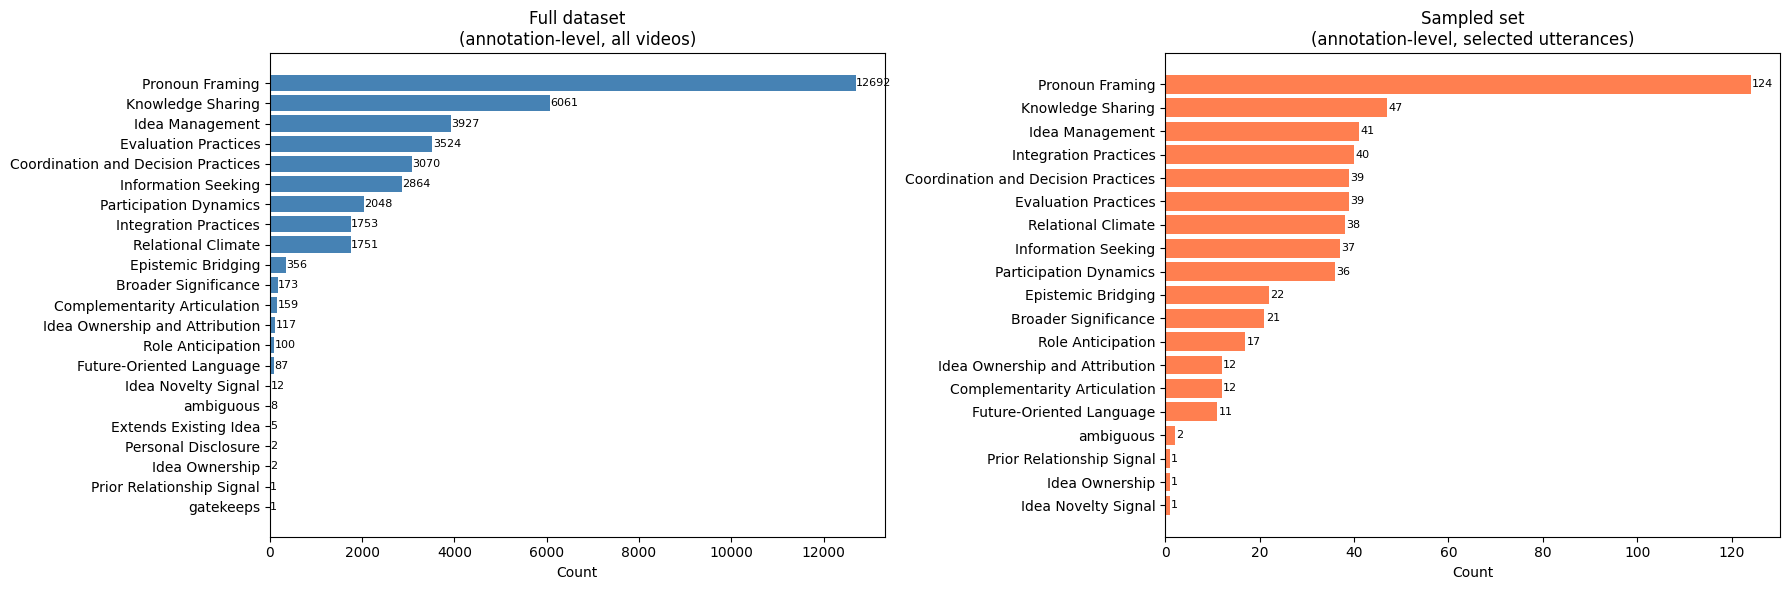

Saved → analysis_v2/notebooks/sampled_v2_distribution.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# before — global dataset
before_vc = pd.Series(dict(global_code_freq)).sort_values()
before_vc = before_vc[before_vc > 0]
axes[0].barh(before_vc.index, before_vc.values, color='steelblue')
axes[0].set_title('Full dataset\n(annotation-level, all videos)', fontsize=12)
axes[0].set_xlabel('Count')
for i, v in enumerate(before_vc.values):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=8)

# after — sampled
after_vc = pd.Series(dict(running)).sort_values()
axes[1].barh(after_vc.index, after_vc.values, color='coral')
axes[1].set_title('Sampled set\n(annotation-level, selected utterances)', fontsize=12)
axes[1].set_xlabel('Count')
for i, v in enumerate(after_vc.values):
    axes[1].text(v + 0.3, i, str(v), va='center', fontsize=8)

plt.tight_layout()
plt.savefig(DIST_PNG, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {DIST_PNG}')

## 5 · Save output Excel

In [6]:
for col in ['c1', 'c1-vf', 'c1-ep', 'c2', 'c2-vf', 'c2-ep', 'c3', 'c3-vf', 'c3-ep', 'notes']:
    df_sample[col] = ''

OUTPUT_COLS = [
    # locators
    'conf', 'session', 'video', 'chunk_file', 'file_path',
    'timestamp', 'speaker', 'transcript',
    # Gemini justification — context for human raters
    'ai_annotations',
    # human annotation slots (matching ev-verification.csv style)
    'c1', 'c1-vf', 'c1-ep',
    'c2', 'c2-vf', 'c2-ep',
    'c3', 'c3-vf', 'c3-ep',
    'notes',
    # behavioural features
    'speaking_duration', 'nod_count', 'shared_affect', 'any_smile_other',
    'distracted_count', 'interruption_type', 'overlap', 'vocal_enthusiasm',
    # AI code labels — far right so they don't bias raters
    'code_names',
]

df_out = df_sample[OUTPUT_COLS]
os.makedirs(os.path.dirname(OUTPUT_EXCEL), exist_ok=True)
df_out.to_excel(OUTPUT_EXCEL, index=False)
print(f'Saved {len(df_out):,} rows → {OUTPUT_EXCEL}')
print(f'Columns: {df_out.columns.tolist()}')

Saved 226 rows → analysis_v2/notebooks/sampled_v2.xlsx
Columns: ['conf', 'session', 'video', 'chunk_file', 'file_path', 'timestamp', 'speaker', 'transcript', 'ai_annotations', 'c1', 'c1-vf', 'c1-ep', 'c2', 'c2-vf', 'c2-ep', 'c3', 'c3-vf', 'c3-ep', 'notes', 'speaking_duration', 'nod_count', 'shared_affect', 'any_smile_other', 'distracted_count', 'interruption_type', 'overlap', 'vocal_enthusiasm', 'code_names']


## 6 · Summary

In [7]:
print('=' * 60)
print('SAMPLING SUMMARY')
print('=' * 60)
print(f'Total unique videos          : {total_videos}')
print(f'Videos sampled (≈20%)        : {df_sample["video"].nunique()}')
print(f'MAX_CHUNKS_PER_VIDEO         : {MAX_CHUNKS_PER_VIDEO}')
print(f'UTTERANCES_PER_CHUNK         : {UTTERANCES_PER_CHUNK}')
print(f'Total utterances in output   : {len(df_out)}')
print()
print('By conference:')
print(df_out.groupby('conf').size().rename('n_utterances').to_string())
print()
print('Code distribution in sample:')
for code, cnt in sorted(running.items(), key=lambda x: -x[1]):
    bar = '█' * (cnt // 2)
    print(f'  {cnt:4d}  {code:<45s} {bar}')
print()
print(f'Output : {OUTPUT_EXCEL}')

SAMPLING SUMMARY
Total unique videos          : 228
Videos sampled (≈20%)        : 45
MAX_CHUNKS_PER_VIDEO         : 3
UTTERANCES_PER_CHUNK         : 2
Total utterances in output   : 226

By conference:
conf
2020NES    16
2021ABI    18
2021CMC    32
2021MND    32
2021MZT    34
2021NES    36
2021SLU    26
2022MND    32

Code distribution in sample:
   124  Pronoun Framing                               ██████████████████████████████████████████████████████████████
    47  Knowledge Sharing                             ███████████████████████
    41  Idea Management                               ████████████████████
    40  Integration Practices                         ████████████████████
    39  Coordination and Decision Practices           ███████████████████
    39  Evaluation Practices                          ███████████████████
    38  Relational Climate                            ███████████████████
    37  Information Seeking                           ██████████████████
    36  Pa